<a href="https://colab.research.google.com/github/sangosei7/Data-Science-Portfolio/blob/main/Spotify_Pulse_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías cargadas correctamente. ¡Listo para empezar!")

Librerías cargadas correctamente. ¡Listo para empezar!


In [ ]:
import pandas as pd

# Pegamos la ruta que copiaste aquí adentro
ruta = '/content/spotify_data clean.csv'

# Cargamos el archivo
df = pd.read_csv(ruta)

# Confirmamos que cargó mostrando las primeras 5 filas
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


# 1. ¿Cuántos datos nulos hay por columna?

In [ ]:
print("Datos faltantes por columna:")
print(df.isnull().sum())

Datos faltantes por columna:
track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64


# 2. ¿Cuáles son los 10 artistas más populares de mi lista?

In [ ]:
top_artistas = df.nlargest(10, 'artist_popularity')[['artist_name', 'artist_popularity']].drop_duplicates()
print("\nTop 10 Artistas más populares:")
print(top_artistas)


Top 10 Artistas más populares:
     artist_name  artist_popularity
78  Taylor Swift                100


# 1. Borramos los 3 artistas sin nombre (son muy pocos, no duelen) / We erase the n3 nameless artist (They are just a few, it does not hurt)

In [ ]:
df = df.dropna(subset=['artist_name'])

# 2. Rellenamos los géneros faltantes con "unknown"/ We fill the missing genres with "unknown"

In [ ]:
df['artist_genres'] = df['artist_genres'].fillna('unknown')

In [ ]:
# La forma correcta y profesional de hacerlo:
df.loc[:, 'artist_genres'] = df['artist_genres'].fillna('unknown')

# Y para estar 100% seguros de que no heredas "vicios" de antes,
# vamos a hacer una copia limpia del DataFrame:
df = df.copy()

print("¡Limpieza exitosa y sin advertencias!")

¡Limpieza exitosa y sin advertencias!


# 3. Verificamos que ya no existan nulos / We verify there are no nules.

In [ ]:
print("Nulos después de la limpieza:")
print(df.isnull().sum())

Nulos después de la limpieza:
track_id              0
track_name            0
track_number          0
track_popularity      0
explicit              0
artist_name           0
artist_popularity     0
artist_followers      0
artist_genres         0
album_id              0
album_name            0
album_release_date    0
album_total_tracks    0
album_type            0
track_duration_min    0
dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo / We set the style

<Axes: xlabel='track_duration_min', ylabel='Count'>

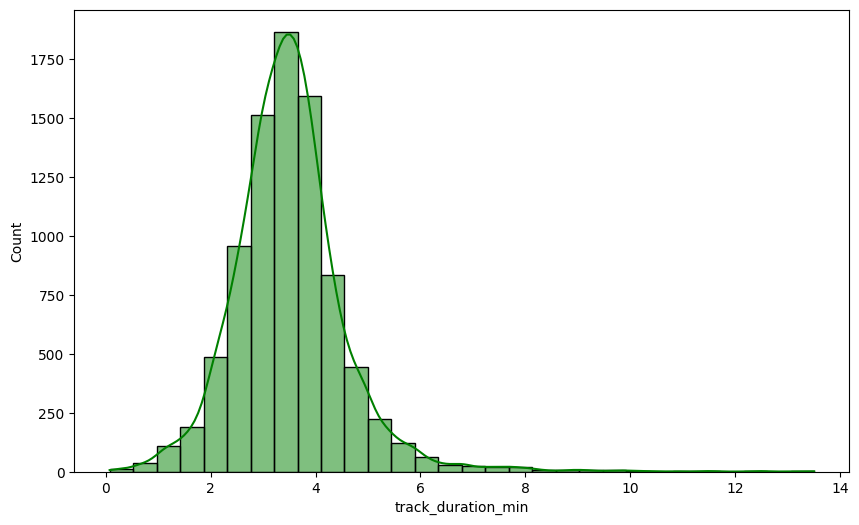

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['track_duration_min'], bins=30, kde=True, color='green')

# Títulos profesionales / Profesional Titles

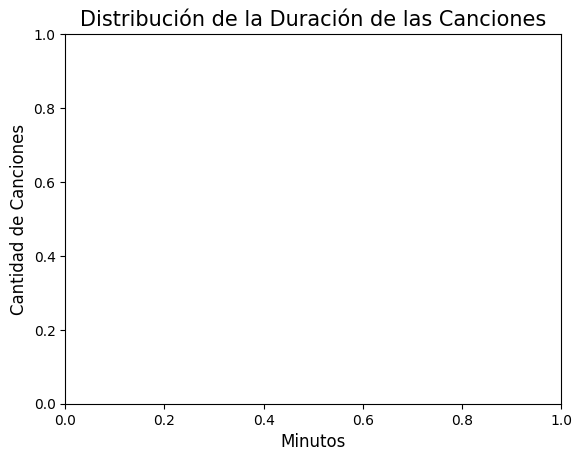

In [ ]:
plt.title('Distribución de la Duración de las Canciones', fontsize=15)
plt.xlabel('Minutos', fontsize=12)
plt.ylabel('Cantidad de Canciones', fontsize=12)

plt.show()

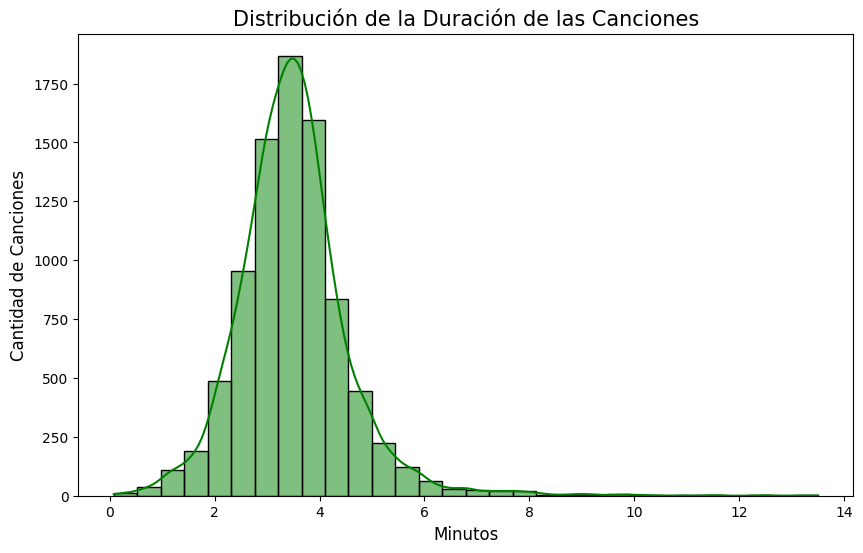

In [ ]:
# 1. Definimos el tamaño de la figura
plt.figure(figsize=(10, 6))

# 2. CREAMOS la gráfica (esta es la parte que faltaba en tu celda)
sns.histplot(df['track_duration_min'], bins=30, kde=True, color='green')

# 3. Ponemos los títulos (los que ya tenías)
plt.title('Distribución de la Duración de las Canciones', fontsize=15)
plt.xlabel('Minutos', fontsize=12)
plt.ylabel('Cantidad de Canciones', fontsize=12)

# 4. Mostramos el resultado final
plt.show()

# Vamos a ver los géneros más frecuentes (sin contar los 'unknown') / Let's see the most frequent genres (without the "Unknown")

/tmp/ipykernel_9893/2537437597.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette='viridis')


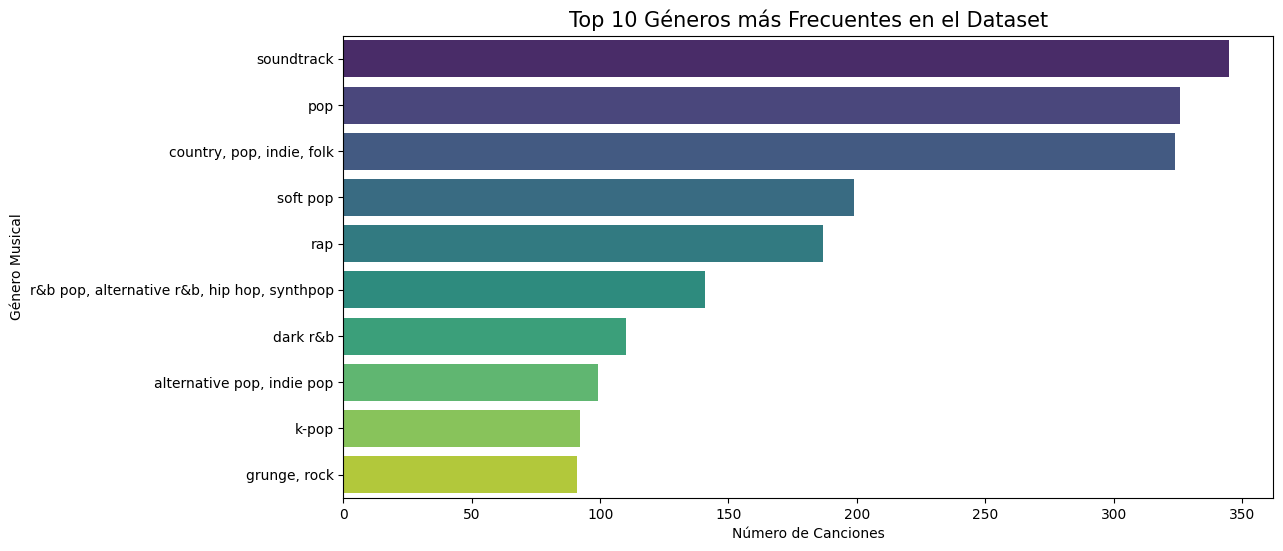

In [ ]:
top_generos = df[df['artist_genres'] != 'unknown']['artist_genres'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_generos.values, y=top_generos.index, palette='viridis')

plt.title('Top 10 Géneros más Frecuentes en el Dataset', fontsize=15)
plt.xlabel('Número de Canciones')
plt.ylabel('Género Musical')
plt.show()

In [ ]:
# Promedio de duración de las canciones de Taylor Swift vs El resto
duracion_taylor = df[df['artist_name'] == 'Taylor Swift']['track_duration_min'].mean()
duracion_total = df['track_duration_min'].mean()

print(f"Duración promedio Taylor Swift: {duracion_taylor:.2f} min")
print(f"Duración promedio general: {duracion_total:.2f} min")

Duración promedio Taylor Swift: 3.90 min
Duración promedio general: 3.49 min


# Calculate the most frequent genres excluding 'unknown'


In [ ]:
top_genres = df[df['artist_genres'] != 'unknown']['artist_genres'].value_counts().head(10)
top_genres

,count
artist_genres,
soundtrack,345
pop,326
"country, pop, indie, folk",324
soft pop,199
rap,187
"r&b pop, alternative r&b, hip hop, synthpop",141
dark r&b,110
"alternative pop, indie pop",99
k-pop,92


<Axes: ylabel='artist_genres'>

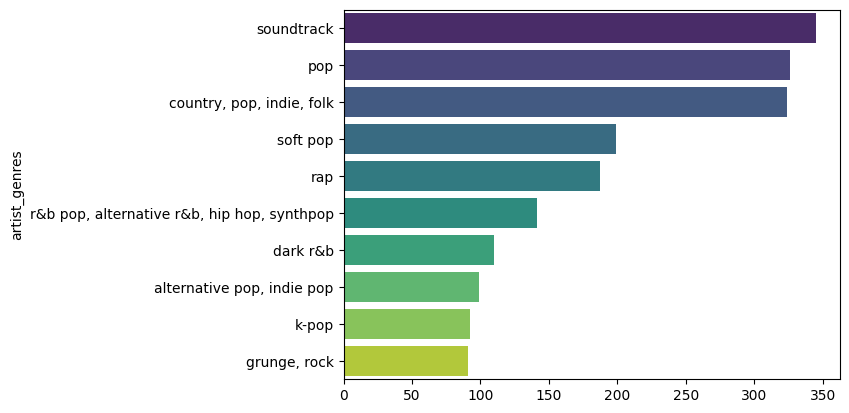

In [ ]:
sns.barplot(x=top_generos.values, y=top_generos.index, hue=top_generos.index, palette='viridis', legend=False)

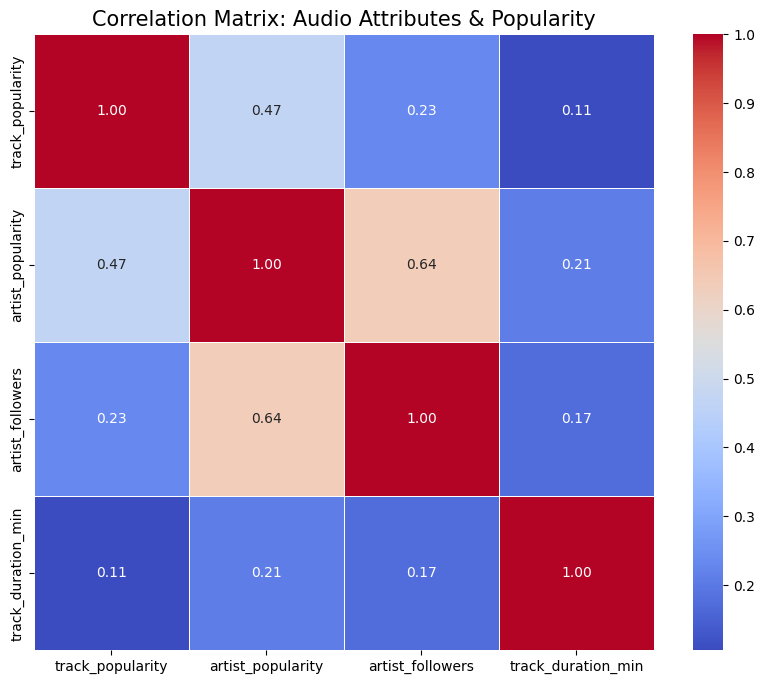

In [ ]:
# Select only numerical columns for correlation
numerical_df = df[['track_popularity', 'artist_popularity', 'artist_followers', 'track_duration_min']]

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix: Audio Attributes & Popularity', fontsize=15)
plt.show()

## ANALISIS TÉCNICO

Interpretación de tu Heatmap

Artist Popularity vs. Followers (0.64): Esta es tu correlación más fuerte (después de las diagonales). Significa que hay una relación sólida: a más seguidores, más popularidad del artista. Es lógico, pero el 0.64 indica que no es una regla absoluta; hay artistas con pocos seguidores que logran ser muy populares (quizás por un hit viral).

Track Popularity vs. Artist Popularity (0.47): Es una correlación moderada. Esto nos dice que ser un artista famoso ayuda a que tu canción sea exitosa, pero no lo garantiza. ¡Incluso Taylor Swift puede sacar una canción que no sea hit!

Duration (0.11 - 0.21): Los números son muy bajos y azules. Esto significa que a la gente no le importa si la canción dura 2 o 5 minutos para que sea popular. La duración no es un factor determinante para el éxito en este dataset.

In [ ]:
# Artistas con alta popularidad (>80) y canciones cortas (<2.5 min)
hidden_gems = df[(df['track_popularity'] > 80) & (df['track_duration_min'] < 2.5)]
print("Canciones cortas y exitosas (Potential TikTok hits):")
print(hidden_gems[['track_name', 'artist_name', 'track_duration_min', 'track_popularity']])

Canciones cortas y exitosas (Potential TikTok hits):
                                   track_name                    artist_name  \
51                           PIXELATED KISSES                           Joji   
247                     When Did You Get Hot?              Sabrina Carpenter   
449                                   Phantom                       EsDeeKid   
503   Just Keep Watching (From F1® The Movie)                     Tate McRae   
539                                   Illegal                 PinkPantheress   
554                                    Gnarly                        KATSEYE   
641                               like JENNIE                         JENNIE   
1005                                    Touch                        KATSEYE   
1175                 PASSO BEM SOLTO - Slowed                          ATLXS   
1421                        run for the hills                     Tate McRae   
1467                         NIGHTS LIKE THIS                  The 

--- REPORT FOR: TAYLOR SWIFT ---
Popularity Score: 100/100
Followers: 145,443,567
Genres: country, pop, indie, folk
Average song duration: 3.90 min
------------------------------


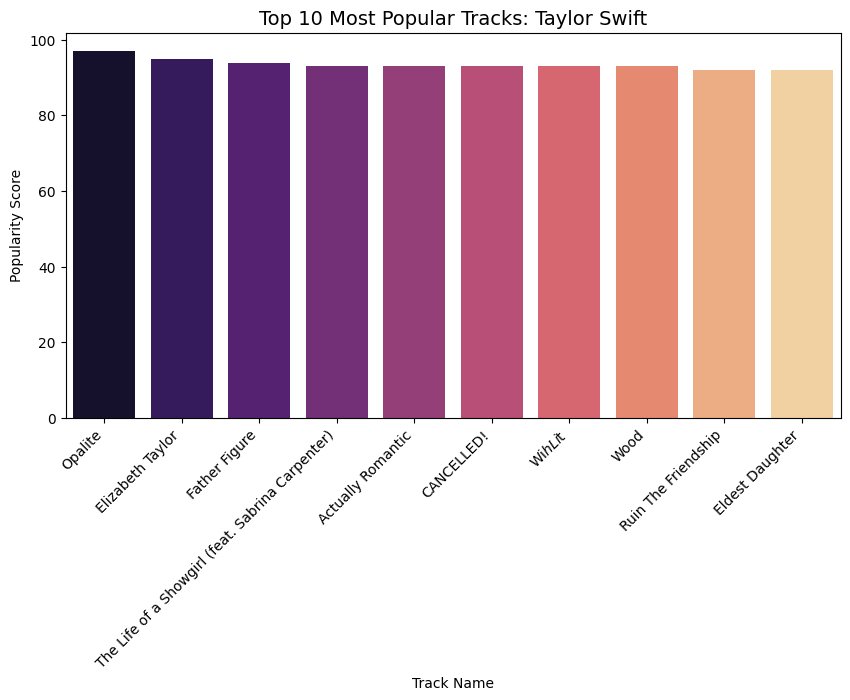

In [ ]:
def analyze_artist(artist_name):
    """
    Función maestra para analizar cualquier artista en el dataset.
    Muestra: Popularidad, seguidores, géneros y el Top 10 de canciones.
    """
    # 1. Filtramos el dataset por el artista (esto crea la variable artist_data)
    artist_data = df[df['artist_name'].str.lower() == artist_name.lower()]

    if artist_data.empty:
        return f"Lo siento, '{artist_name}' no se encuentra en este dataset."

    # 2. Extraemos métricas clave
    pop = artist_data['artist_popularity'].iloc[0]
    followers = artist_data['artist_followers'].iloc[0]
    genres = artist_data['artist_genres'].unique()
    avg_duration = artist_data['track_duration_min'].mean()

    # 3. Imprimimos el reporte
    print(f"--- REPORT FOR: {artist_name.upper()} ---")
    print(f"Popularity Score: {pop}/100")
    print(f"Followers: {followers:,}")
    print(f"Genres: {', '.join(genres)}")
    print(f"Average song duration: {avg_duration:.2f} min")
    print("-" * 30)

    # 4. Seleccionamos solo el Top 10 para la gráfica
    top_10_tracks = artist_data.nlargest(10, 'track_popularity')

    # 5. Creamos la gráfica
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_10_tracks['track_name'],
                y=top_10_tracks['track_popularity'],
                hue=top_10_tracks['track_name'],
                palette='magma',
                legend=False)

    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top 10 Most Popular Tracks: {artist_name}', fontsize=14)
    plt.ylabel('Popularity Score')
    plt.xlabel('Track Name')
    plt.show()

# --- AHORA PRUEBA LA FUNCIÓN AQUÍ ---
analyze_artist('Taylor Swift')